In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import load_model

battery_names = ['B0005', 'B0006', 'B0007', 'B0018']

def extract_soh(cycles):
    discharge_capacities = []
    for i in range(cycles.shape[0]):
        cycle = cycles[i]
        if cycle['type'][0] == 'discharge':
            current = cycle['data'][0]['Current_measured'][0][0].flatten()
            time = cycle['data'][0]['Time'][0][0].flatten()
            capacity = np.trapezoid(abs(current), time) / 3600
            discharge_capacities.append(capacity)
    initial = discharge_capacities[0]
    return np.array([cap / initial * 100 for cap in discharge_capacities])

soh_data = {}
for name in battery_names:
    data = scipy.io.loadmat(f'../data/raw/{name}.mat')
    cycles = data[name]['cycle'][0][0][0]
    soh_data[name] = extract_soh(cycles)
    print(f"{name}: {len(soh_data[name])} discharge cycles")

model_lstm = load_model('../outputs/models/lstm_soh.keras')
print("LSTM model loaded")

B0005: 168 discharge cycles
B0006: 168 discharge cycles
B0007: 168 discharge cycles
B0018: 132 discharge cycles
LSTM model loaded


In [2]:
def create_sequences(soh, look_back=10):
    X, y = [], []
    for i in range(len(soh) - look_back):
        X.append(soh[i : i + look_back])
        y.append(soh[i + look_back])
    return np.array(X), np.array(y)

X_train = np.concatenate([create_sequences(soh_data[n])[0] for n in ['B0005', 'B0006', 'B0007']])
y_train = np.concatenate([create_sequences(soh_data[n])[1] for n in ['B0005', 'B0006', 'B0007']])
X_test, y_test = create_sequences(soh_data['B0018'])

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_scaler = MinMaxScaler()
y_scaler.fit(y_train.reshape(-1, 1))

X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

y_pred_lstm = y_scaler.inverse_transform(model_lstm.predict(X_test_lstm))
y_actual = y_test.reshape(-1, 1)

mae_lstm = mean_absolute_error(y_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_actual, y_pred_lstm))

print(f"LSTM — MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step
LSTM — MAE: 1.3590, RMSE: 1.6831


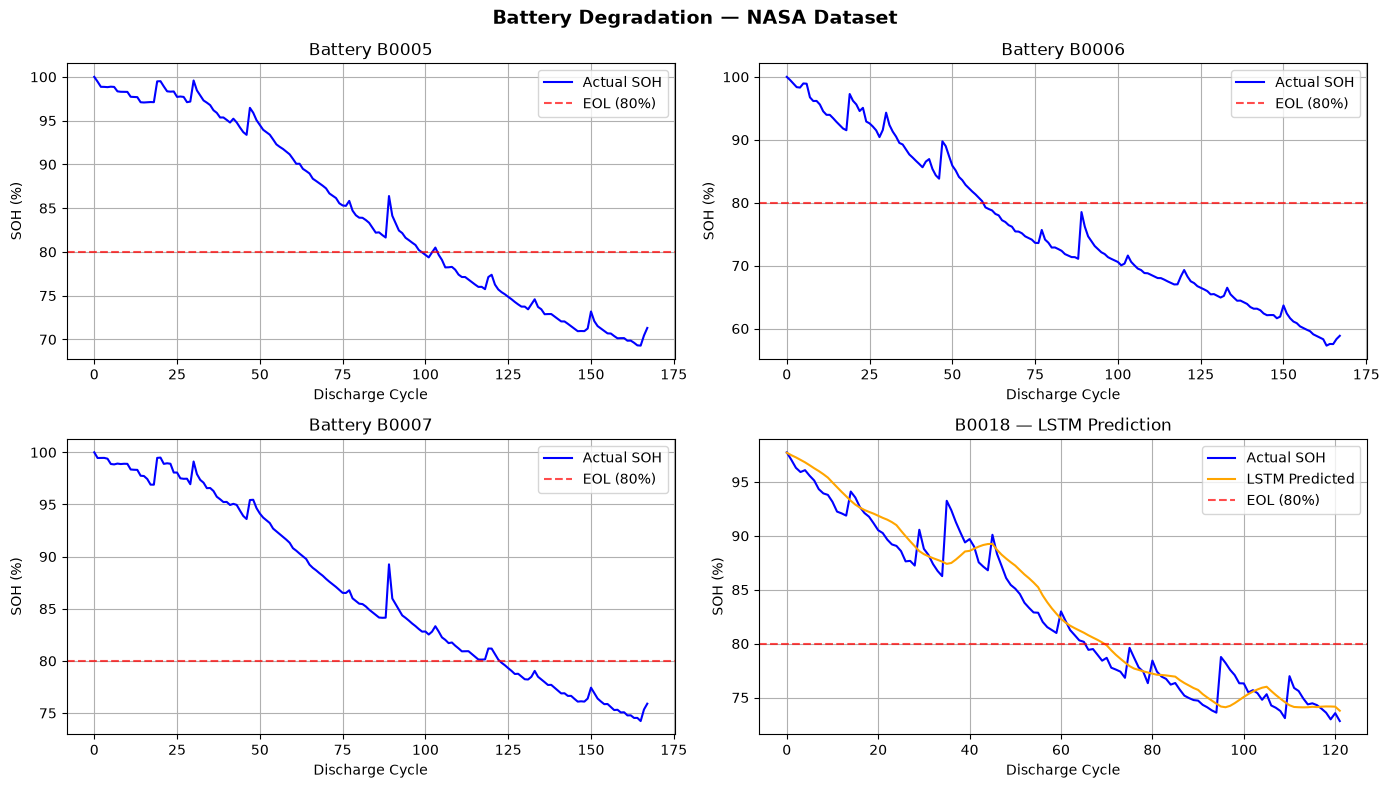

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, name in enumerate(battery_names[:3]):
    axes[idx].plot(soh_data[name], label='Actual SOH', color='blue')
    axes[idx].axhline(y=80, color='red', linestyle='--', label='EOL (80%)', alpha=0.7)
    axes[idx].set_title(f'Battery {name}')
    axes[idx].set_xlabel('Discharge Cycle')
    axes[idx].set_ylabel('SOH (%)')
    axes[idx].legend()
    axes[idx].grid(True)

axes[3].plot(y_actual, label='Actual SOH', color='blue')
axes[3].plot(y_pred_lstm, label='LSTM Predicted', color='orange')
axes[3].axhline(y=80, color='red', linestyle='--', label='EOL (80%)', alpha=0.7)
axes[3].set_title('B0018 — LSTM Prediction')
axes[3].set_xlabel('Discharge Cycle')
axes[3].set_ylabel('SOH (%)')
axes[3].legend()
axes[3].grid(True)

plt.suptitle('Battery Degradation — NASA Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/final_comparison.png', dpi=150)
plt.show()

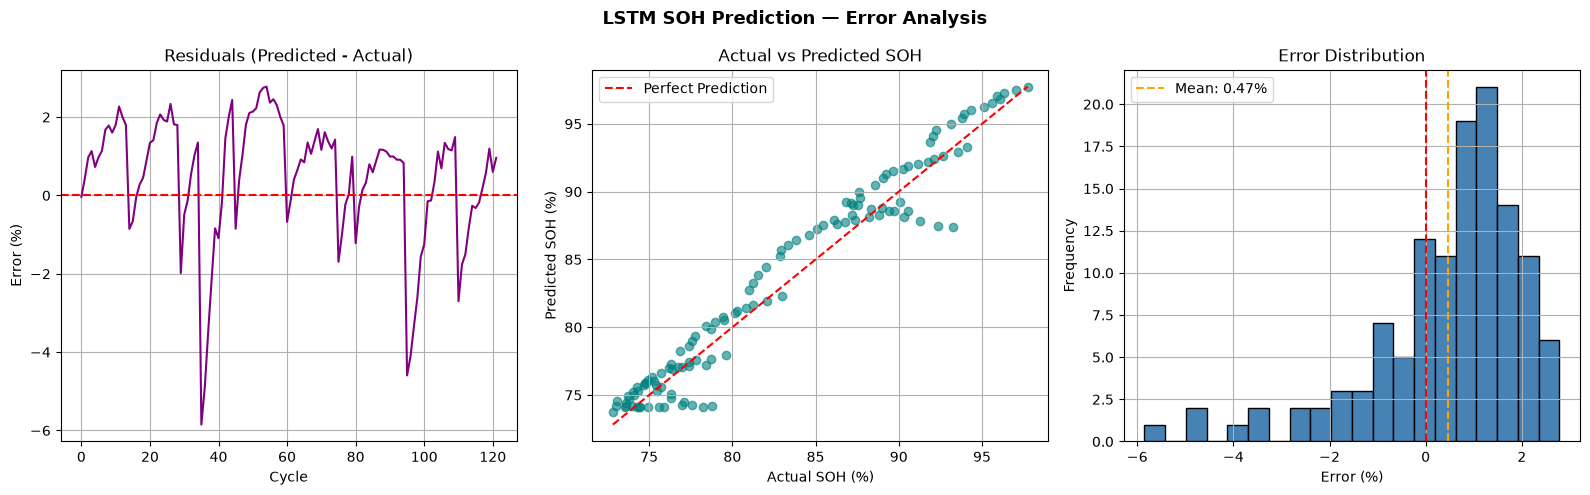

In [5]:
residuals = y_pred_lstm.flatten() - y_actual.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 - Residuals
axes[0].plot(residuals, color='purple')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals (Predicted - Actual)')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Error (%)')
axes[0].grid(True)

# Plot 2 - Scatter
axes[1].scatter(y_actual, y_pred_lstm, alpha=0.6, color='teal')
min_val = min(y_actual.min(), y_pred_lstm.min())
max_val = max(y_actual.max(), y_pred_lstm.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted SOH')
axes[1].set_xlabel('Actual SOH (%)')
axes[1].set_ylabel('Predicted SOH (%)')
axes[1].legend()
axes[1].grid(True)

# Plot 3 - Error distribution
axes[2].hist(residuals, bins=20, color='steelblue', edgecolor='black')
axes[2].axvline(x=0, color='red', linestyle='--')
axes[2].axvline(x=residuals.mean(), color='orange', linestyle='--', label=f'Mean: {residuals.mean():.2f}%')
axes[2].set_title('Error Distribution')
axes[2].set_xlabel('Error (%)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('LSTM SOH Prediction — Error Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/error_analysis.png', dpi=150)
plt.show()

In [7]:
rul_mae = 2.83
rul_rmse = 3.74

print("=" * 45)
print("      FINAL MODEL RESULTS SUMMARY")
print("=" * 45)
print(f"  Dataset:        NASA Li-ion Battery")
print(f"  Train:          B0005, B0006, B0007")
print(f"  Test:           B0018 (unseen battery)")
print(f"  Architecture:   2-layer LSTM")
print(f"  Look-back:      10 cycles")
print("-" * 45)
print(f"  SOH MAE:        {mae_lstm:.2f}%")
print(f"  SOH RMSE:       {rmse_lstm:.2f}%")
print(f"  RUL MAE:        {rul_mae} cycles")
print(f"  RUL RMSE:       {rul_rmse} cycles")
print("-" * 45)
print(f"  Mean Bias:      {residuals.mean():.2f}%")
print(f"  Max Error:      {abs(residuals).max():.2f}%")
print(f"  Errors < 2%:    {(abs(residuals) < 2).sum()}/{len(residuals)} cycles")
print("=" * 45)

      FINAL MODEL RESULTS SUMMARY
  Dataset:        NASA Li-ion Battery
  Train:          B0005, B0006, B0007
  Test:           B0018 (unseen battery)
  Architecture:   2-layer LSTM
  Look-back:      10 cycles
---------------------------------------------
  SOH MAE:        1.36%
  SOH RMSE:       1.68%
  RUL MAE:        2.83 cycles
  RUL RMSE:       3.74 cycles
---------------------------------------------
  Mean Bias:      0.47%
  Max Error:      5.85%
  Errors < 2%:    97/122 cycles
